# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

Welcome to Lab 10! Today we're tackling a classic machine learning challenge: the XOR problem. We'll be building Multilayer Perceptrons (MLPs) using three of the most popular deep learning frameworks: Keras, PyTorch, and TensorFlow. Let's dive in and see how they compare!

## Step 1: Setting up the XOR Dataset

The XOR (exclusive OR) function is a great way to show why we need hidden layers. It outputs `1` only if the inputs are different, and `0` if they are the same:

| Input 1 | Input 2 | XOR Output |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Because this pattern isn't linearly separable (you can't draw a single straight line to separate the 0s and 1s), a simple linear classifier won't cut it. We need an MLP with at least one hidden layer!

In [3]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

print("X:\n", X)
print("y:\n", y)

X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y:
 [[0.]
 [1.]
 [1.]
 [0.]]


## Part 1 — Keras (TensorFlow High-Level API)

Let's start with Keras, which is super intuitive and great for getting a model up and running quickly. 
- **Architecture:** We're keeping it simple: 2 inputs, a hidden layer with 4 neurons (using ReLU), and a single output neuron (using Sigmoid for binary classification).
- **Loss & Optimizer:** Binary Cross-Entropy loss (standard for binary classification) and the Adam optimizer.

In this first block, we build and compile the model, then train it for 500 epochs. Keep an eye on how the loss decreases!

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

keras_model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

keras_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05),
                     loss="binary_crossentropy", metrics=["accuracy"])

history = keras_model.fit(X, y, epochs=500, verbose=0)
print("Final training loss:", history.history["loss"][-1])
print("Final training accuracy:", history.history["accuracy"][-1])

Final training loss: 0.0002663128834683448
Final training accuracy: 1.0


Now that our Keras model is trained, let's see how well it learned the XOR logic. We'll ask it to predict the outputs for all 4 possible input combinations and round the results to 0 or 1.

In [5]:
keras_preds = keras_model.predict(X, verbose=0)
for i in range(4):
    print(f"Input: {X[i]} -> Predicted: {keras_preds[i][0]:.4f} -> Rounded: {round(keras_preds[i][0])} | True: {int(y[i][0])}")

Input: [0. 0.] -> Predicted: 0.0003 -> Rounded: 0 | True: 0
Input: [0. 1.] -> Predicted: 0.9997 -> Rounded: 1 | True: 1
Input: [1. 0.] -> Predicted: 0.9998 -> Rounded: 1 | True: 1
Input: [1. 1.] -> Predicted: 0.0002 -> Rounded: 0 | True: 0


Visualizing the training process helps us understand how quickly the model is learning. Let's plot the training loss curve for our Keras model.

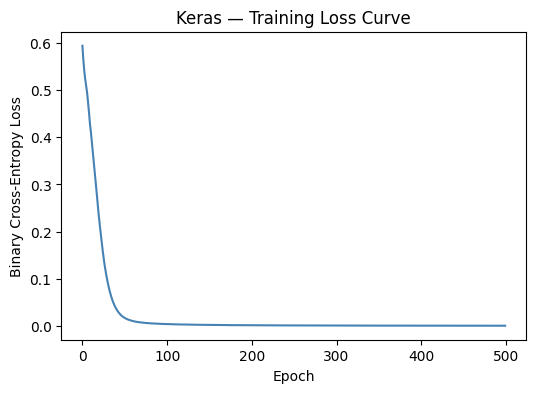

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], color="steelblue")
plt.title("Keras — Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

## Part 2 — PyTorch

Next up is PyTorch! PyTorch is loved for its dynamic computation graph and Pythonic feel. We'll define the exact same architecture we used in Keras, but using PyTorch's `nn.Module` class.

First, we convert our numpy arrays to PyTorch tensors, set up the network structure (`XORNet`), and define our loss function (`BCELoss`) and optimizer.

## Part 2 — PyTorch

**Architecture:** Input(2) -> Linear(4) + ReLU -> Linear(1) + Sigmoid
**Loss:** Binary Cross-Entropy (BCELoss), **Optimizer:** Adam

In [7]:
import torch
import torch.nn as nn

torch.manual_seed(42)

X_t = torch.tensor(X)
y_t = torch.tensor(y)

class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

torch_model = XORNet()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(torch_model.parameters(), lr=0.05)

Unlike Keras where we just call `.fit()`, PyTorch requires us to write our own training loop. This gives us total control over the forward pass, loss calculation, backpropagation, and weight updates. Let's run it for 500 epochs!

In [8]:
torch_losses = []
epochs = 500

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = torch_model(X_t)
    loss = criterion(outputs, y_t)
    loss.backward()
    optimizer.step()
    torch_losses.append(loss.item())

print("Final training loss:", torch_losses[-1])

Final training loss: 0.0019634508062154055


Time to test our PyTorch model. We'll use `torch.no_grad()` to tell PyTorch we don't need to track gradients for predictions, which saves memory and speeds things up.

In [9]:
with torch.no_grad():
    torch_preds = torch_model(X_t)

for i in range(4):
    pred = torch_preds[i].item()
    print(f"Input: {X[i]} -> Predicted: {pred:.4f} -> Rounded: {round(pred)} | True: {int(y[i][0])}")

Input: [0. 0.] -> Predicted: 0.0005 -> Rounded: 0 | True: 0
Input: [0. 1.] -> Predicted: 0.9995 -> Rounded: 1 | True: 1
Input: [1. 0.] -> Predicted: 0.9937 -> Rounded: 1 | True: 1
Input: [1. 1.] -> Predicted: 0.0006 -> Rounded: 0 | True: 0


Let's check out the loss curve for PyTorch to see if it converges as smoothly as Keras did.

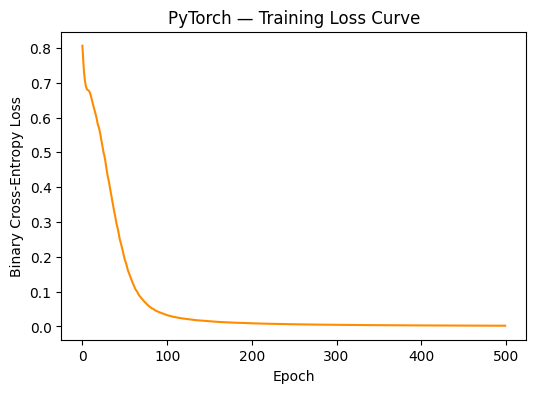

In [10]:
plt.figure(figsize=(6,4))
plt.plot(torch_losses, color="darkorange")
plt.title("PyTorch — Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

## Part 3 — TensorFlow Low-Level API

For our final implementation, we're going under the hood with TensorFlow's low-level API. Instead of using `keras.Sequential`, we'll manually define the weights and biases as `tf.Variable` objects.

This block sets up the variables and creates a manual `forward` function to calculate our network's predictions step-by-step.

## Part 3 — TensorFlow Low-Level API

Instead of `keras.Sequential`, the weights, forward pass, loss, and gradient updates are written explicitly using `tf.Variable` and `tf.GradientTape`.

In [11]:
tf.random.set_seed(42)

W1 = tf.Variable(tf.random.normal([2,4], stddev=0.5))
b1 = tf.Variable(tf.zeros([4]))
W2 = tf.Variable(tf.random.normal([4,1], stddev=0.5))
b2 = tf.Variable(tf.zeros([1]))

X_tf = tf.constant(X)
y_tf = tf.constant(y)

def forward(x):
    hidden = tf.nn.relu(tf.matmul(x, W1) + b1)
    out = tf.nn.sigmoid(tf.matmul(hidden, W2) + b2)
    return out

optimizer_tf = tf.optimizers.Adam(learning_rate=0.05)

Here's where the magic happens. We'll use `tf.GradientTape()` to manually track the operations in our forward pass, calculate the gradients, and update our variables using the Adam optimizer.

In [12]:
tf_losses = []
epochs = 500

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        preds = forward(X_tf)
        loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_tf, preds))
    grads = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer_tf.apply_gradients(zip(grads, [W1, b1, W2, b2]))
    tf_losses.append(loss.numpy())

print("Final training loss:", tf_losses[-1])

Final training loss: 0.0008503475


Let's see if all that manual math paid off! We'll run our inputs through the `forward` function and check the predictions.

In [13]:
tf_preds = forward(X_tf).numpy()
for i in range(4):
    pred = tf_preds[i][0]
    print(f"Input: {X[i]} -> Predicted: {pred:.4f} -> Rounded: {round(pred)} | True: {int(y[i][0])}")

Input: [0. 0.] -> Predicted: 0.0013 -> Rounded: 0 | True: 0
Input: [0. 1.] -> Predicted: 0.9995 -> Rounded: 1 | True: 1
Input: [1. 0.] -> Predicted: 0.9998 -> Rounded: 1 | True: 1
Input: [1. 1.] -> Predicted: 0.0013 -> Rounded: 0 | True: 0


And finally, let's plot the loss curve for our custom TensorFlow implementation.

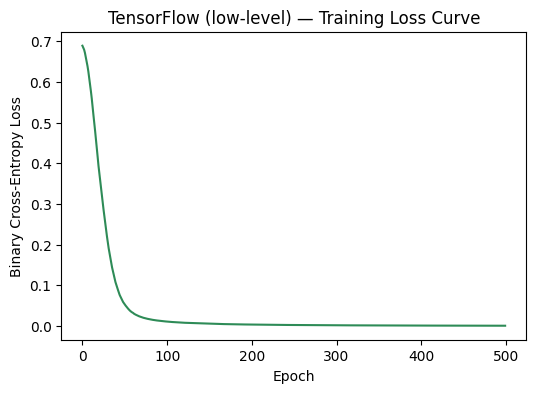

In [14]:
plt.figure(figsize=(6,4))
plt.plot(tf_losses, color="seagreen")
plt.title("TensorFlow (low-level) — Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.show()

## Part 4: Comparing the Three Implementations

Now that we've built the same model three different ways, let's put their training curves side-by-side to see how they stack up.

## Comparison of the Three Implementations

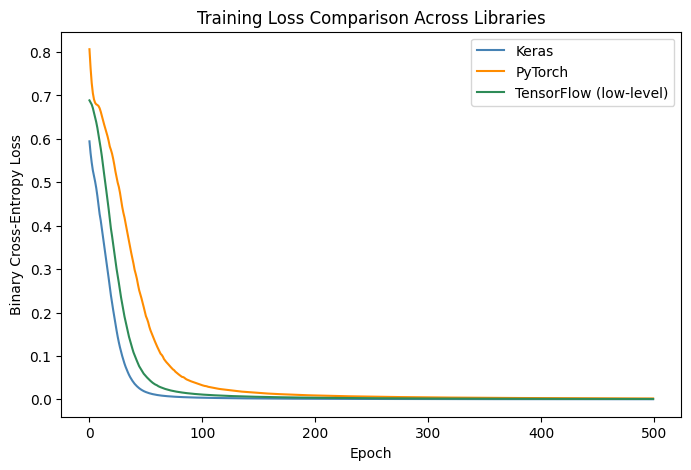

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Keras", color="steelblue")
plt.plot(torch_losses, label="PyTorch", color="darkorange")
plt.plot(tf_losses, label="TensorFlow (low-level)", color="seagreen")
plt.title("Training Loss Comparison Across Libraries")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.show()

## Discussion: The Effect of Hyperparameters

We played around with several hyperparameters during this lab. Here's a quick breakdown of what they do and how they affect our MLP's ability to learn XOR:

- **Learning rate:** Think of this as the "step size" our model takes while learning. A very small learning rate (e.g., 0.001) makes the model learn very slowly, requiring thousands of epochs. A large one (e.g., 0.5) can cause the model to jump around erratically and never actually settle on a good solution.
- **Activation function:** We used ReLU in the hidden layer, which works great because it helps avoid the "vanishing gradient" problem that can happen with Sigmoid or Tanh. It's fast and reliable.
- **Number of neurons:** We used 4 neurons in our hidden layer, but you need *at least* 2 to learn the XOR pattern. More neurons (like 4) give the model more flexibility and help it converge faster.
- **Epochs:** This is the number of times the model sees the entire dataset. 50 epochs simply isn't enough time to figure out the complex XOR logic, but 300-500 epochs gave all our models plenty of time to fully converge.

**The Takeaway:** The network's architecture (number of neurons and activation functions) determines *if* the model can solve the problem at all, while the learning rate and epochs determine *how quickly* it gets there.

## Final Conclusion

In this lab, we proved that a Multilayer Perceptron (MLP) with just a single hidden layer can successfully conquer the non-linear XOR problem! 

More importantly, we saw firsthand that the underlying math—forward passes, loss calculations, backpropagation, and gradient descent—is exactly the same whether you use a high-level API like Keras, a dynamic framework like PyTorch, or manually code the operations with TensorFlow. The choice of library is just about which workflow fits your project best!

## Conclusion

An MLP with a single hidden layer of ReLU-activated neurons successfully learns the non-linear XOR function, which a single-layer perceptron cannot. The same architecture was implemented three ways — Keras's high-level `Sequential` API, PyTorch's `nn.Module` with a manual training loop, and TensorFlow's low-level `tf.GradientTape` API — and all three converged to correct predictions for all four XOR input combinations, confirming that the underlying mathematics (forward pass, backpropagation, gradient descent) is identical regardless of the framework used to express it.

## Bonus: Visualizing the Decision Boundary

As an optional exercise, it's really cool to actually *see* how our models are separating the 0s and 1s. Let's plot the decision boundary for our Keras model! We'll create a grid of points, ask the model to predict the outcome for every point on the grid, and color-code the results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a mesh grid
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

# Get predictions from the Keras model
Z = keras_model.predict(grid, verbose=0)
Z = np.round(Z).reshape(xx.shape)

# Plot the contour and the original data points
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='bwr', edgecolor='k', s=100)
plt.title("Keras MLP Decision Boundary for XOR")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()